In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

In [ ]:
df = df.drop_duplicates()

df = df.dropna()

print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


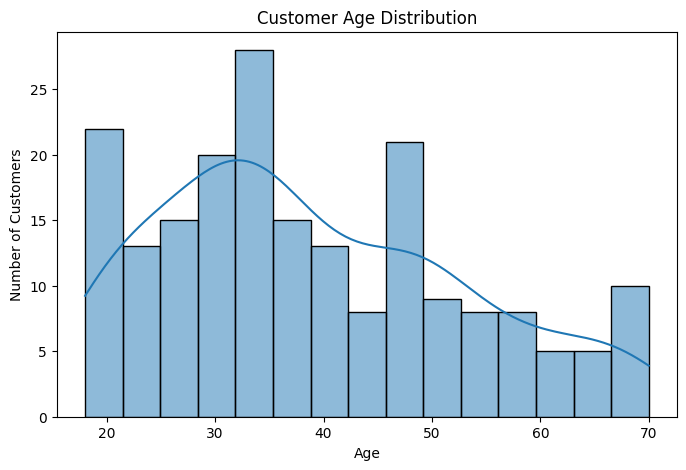

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

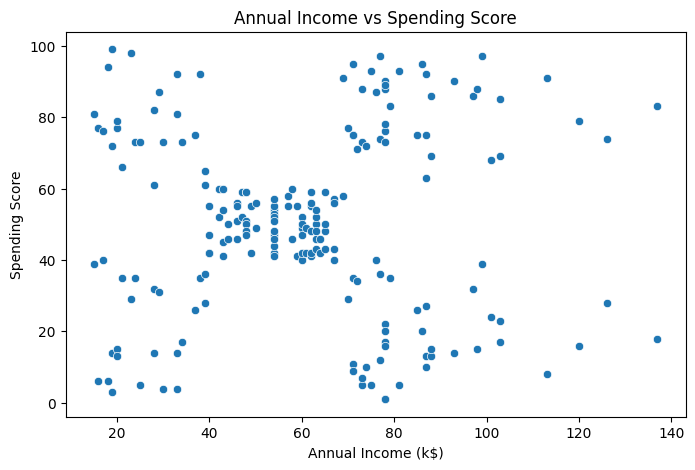

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [ ]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

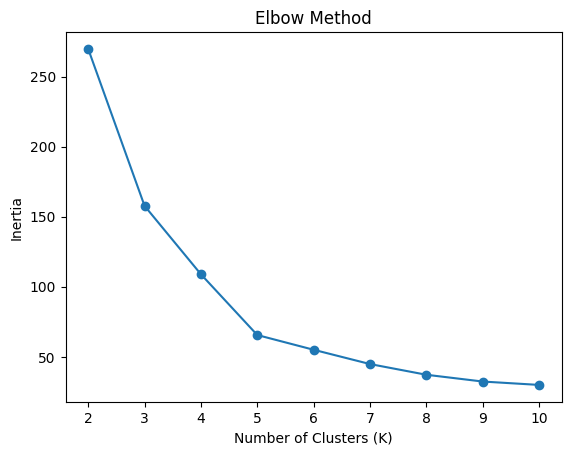

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


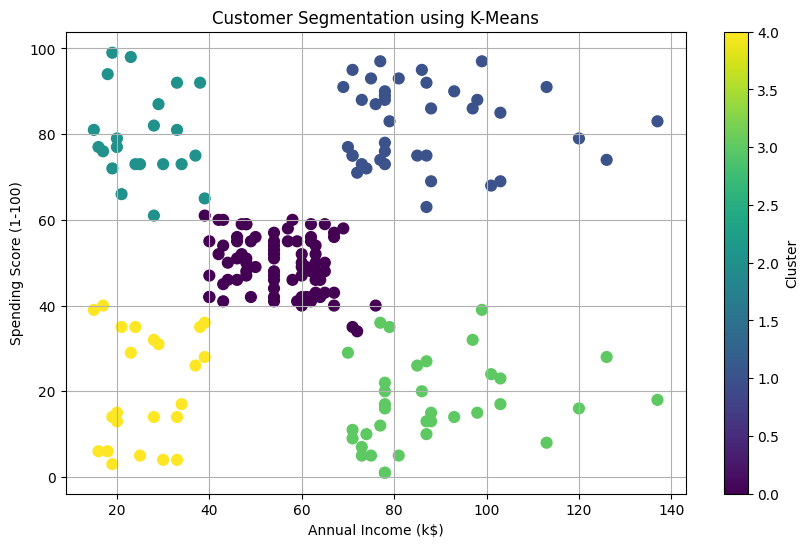

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.colorbar(label='Cluster')
plt.grid(True)

plt.show()

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [ ]:
### Customer Segmentation Conclusion

### The K-Means clustering algorithm was applied to segment 200 mall customers based on their annual income and spending score. The Elbow Method was used to determine the optimal number of clusters, and K = 5 was selected. The customers were successfully divided into five distinct groups with different income and spending behaviors. These segments can help businesses understand customer characteristics and develop targeted marketing strategies.


In [ ]:
df.to_csv('customer_segmentation.csv', index=False)

print("Dataset saved successfully!")
print(df.shape)

Dataset saved successfully!
(200, 6)


In [ ]:
!pip install streamlit plotly pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.5 MB/s eta 0:00:00


In [ ]:
print(df.columns.tolist())
print(df.shape)

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']
(200, 6)


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

# -----------------------------
# PAGE CONFIGURATION
# -----------------------------

st.set_page_config(
    page_title="Customer Analytics",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

# -----------------------------
# CUSTOM CSS
# -----------------------------

st.markdown("""
<style>

    .main {
        background-color: #F8FAFC;
    }

    .block-container {
        padding-top: 2rem;
        padding-bottom: 2rem;
    }

    .dashboard-title {
        font-size: 32px;
        font-weight: 700;
        color: #0F172A;
    }

    .dashboard-subtitle {
        color: #64748B;
        font-size: 15px;
        margin-bottom: 25px;
    }

    .metric-card {
        background-color: white;
        border: 1px solid #E2E8F0;
        border-radius: 12px;
        padding: 20px;
        min-height: 120px;
    }

    .metric-label {
        color: #64748B;
        font-size: 14px;
    }

    .metric-value {
        color: #0F172A;
        font-size: 28px;
        font-weight: 700;
    }

    .section-title {
        color: #0F172A;
        font-size: 21px;
        font-weight: 600;
        margin-top: 25px;
    }

</style>
""", unsafe_allow_html=True)

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv("customer_segmentation.csv")

# -----------------------------
# HEADER
# -----------------------------

st.markdown(
    '<div class="dashboard-title">Customer Analytics</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="dashboard-subtitle">'
    'Understand your customers and make smarter marketing decisions.'
    '</div>',
    unsafe_allow_html=True
)

# -----------------------------
# SIDEBAR FILTERS
# -----------------------------

st.sidebar.title("Dashboard Filters")

st.sidebar.markdown(
    "Use the filters to explore customer segments."
)

selected_cluster = st.sidebar.selectbox(
    "Select Customer Segment",
    ["All"] + sorted(df["Cluster"].unique().tolist())
)

age_range = st.sidebar.slider(
    "Age Range",
    int(df["Age"].min()),
    int(df["Age"].max()),
    (
        int(df["Age"].min()),
        int(df["Age"].max())
    )
)

income_range = st.sidebar.slider(
    "Annual Income (k$)",
    int(df["Annual Income (k$)"].min()),
    int(df["Annual Income (k$)"].max()),
    (
        int(df["Annual Income (k$)"].min()),
        int(df["Annual Income (k$)"].max())
    )
)

# -----------------------------
# FILTER DATA
# -----------------------------

filtered_df = df[
    (df["Age"] >= age_range[0]) &
    (df["Age"] <= age_range[1]) &
    (df["Annual Income (k$)"] >= income_range[0]) &
    (df["Annual Income (k$)"] <= income_range[1])
]

if selected_cluster != "All":
    filtered_df = filtered_df[
        filtered_df["Cluster"] == selected_cluster
    ]

# -----------------------------
# SUMMARY CARDS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">Total Customers</div>
            <div class="metric-value">{len(filtered_df)}</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">Customer Segments</div>
            <div class="metric-value">
                {filtered_df["Cluster"].nunique()}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:
    avg_income = filtered_df["Annual Income (k$)"].mean()

    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">Average Income</div>
            <div class="metric-value">{avg_income:.2f}k</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col4:
    avg_spending = filtered_df["Spending Score (1-100)"].mean()

    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">Average Spending</div>
            <div class="metric-value">{avg_spending:.2f}</div>
        </div>
        """,
        unsafe_allow_html=True
    )

# -----------------------------
# CHARTS
# -----------------------------

st.markdown(
    '<div class="section-title">Customer Insights</div>',
    unsafe_allow_html=True
)

chart_col1, chart_col2 = st.columns(2)

with chart_col1:

    st.subheader("Customer Segment Distribution")

    segment_counts = (
        filtered_df["Cluster"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    segment_counts.columns = ["Cluster", "Customers"]

    fig_bar = px.bar(
        segment_counts,
        x="Cluster",
        y="Customers",
        color="Cluster",
        title="Customers by Segment"
    )

    fig_bar.update_layout(
        showlegend=False,
        plot_bgcolor="white",
        paper_bgcolor="white"
    )

    st.plotly_chart(
        fig_bar,
        use_container_width=True
    )

with chart_col2:

    st.subheader("Income vs Spending Score")

    fig_scatter = px.scatter(
        filtered_df,
        x="Annual Income (k$)",
        y="Spending Score (1-100)",
        color="Cluster",
        hover_data=["CustomerID", "Age", "Genre"],
        title="Customer Segments"
    )

    fig_scatter.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white"
    )

    st.plotly_chart(
        fig_scatter,
        use_container_width=True
    )

# -----------------------------
# CLUSTER SUMMARY
# -----------------------------

st.markdown(
    '<div class="section-title">Segment Summary</div>',
    unsafe_allow_html=True
)

summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean().round(2)

st.dataframe(
    summary,
    use_container_width=True
)

# -----------------------------
# CUSTOMER DETAILS
# -----------------------------

st.markdown(
    '<div class="section-title">Customer Details</div>',
    unsafe_allow_html=True
)

st.dataframe(
    filtered_df,
    use_container_width=True,
    hide_index=True
)

# -----------------------------
# DOWNLOAD DATA
# -----------------------------

csv_data = filtered_df.to_csv(index=False)

st.download_button(
    label="Download Filtered Customer Data",
    data=csv_data,
    file_name="filtered_customers.csv",
    mime="text/csv"
)

Writing app.py


In [ ]:
!pkill -f streamlit

In [ ]:
from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token("3JoaHN8xrkDJutH28PXLP8qf0uR_62sM5rQpBHhG666QdfHTo")

In [ ]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 &



2026-09-25 10:04:30.659 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.27.255.63:8501

  Stopping...


In [ ]:
import time
time.sleep(6)

In [ ]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://pony-paver-defiance.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!ps aux | grep streamlit

root        5006  0.0  0.0   7344  3584 ?        S    10:12   0:00 /bin/bash -c ps aux | grep streamlit
root        5008  0.0  0.0   6548  2300 ?        S    10:12   0:00 grep streamlit


In [ ]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 &>/content/logs.txt &

In [ ]:
import time
time.sleep(8)

In [ ]:
!ps aux | grep streamlit

root        5166  6.6  0.5 451832 72140 ?        Sl   10:13   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.address 0.0.0.0 --server.port 8501
root        5330  0.0  0.0   7344  3520 ?        S    10:14   0:00 /bin/bash -c ps aux | grep streamlit
root        5332  0.0  0.0   6548  2300 ?        S    10:14   0:00 grep streamlit


In [ ]:
!cat /content/logs.txt



2026-09-25 10:13:30.380 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.27.255.63:8501



In [ ]:
!curl -s http://localhost:8501 | head -5

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.


In [ ]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://pony-paver-defiance.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
scikit-learn

Writing requirements.txt
